# Detecção de Impossible Travel em Logs de Acesso

Este notebook identifica acessos suspeitos baseados na lógica de **viagem impossível** e utiliza **Redes Neurais Recorrentes (LSTM)** para modelar comportamentos de geolocalização, aproveitando a aceleração de hardware **Apple Silicon (M2)**.

### Estrutura do Projeto:
1. **Configuração de Ambiente**: Verificação de suporte a GPU (Metal).
2. **Detecção Determinística**: Baseada em velocidade física (Haversine).
3. **Modelagem Comportamental Global (LSTM)**: Treinamento com contexto de geolocalização e tempo.
4. **Visualização de Performance**: Gráfico de Perda (Loss) vs Validação.
5. **Apresentação de Casos**: Cruzamento de dados físicos e comportamentais.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
from datetime import datetime, timedelta
from IPython.display import display, HTML
import folium
from sklearn.preprocessing import MinMaxScaler

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    
    print("Versão do TensorFlow:", tf.__version__)
    dispositivos_gpu = tf.config.list_physical_devices('GPU')

    if dispositivos_gpu:
        print("\n✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.")
    else:
        print("\n⚠️ Nenhuma GPU detectada. O treinamento ocorrerá na CPU.")
except ImportError:
    print("TensorFlow não encontrado.")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

Versão do TensorFlow: 2.16.2

✅ GPU detectada! O treinamento será acelerado pelo seu chip M2.


## 1. Carregamento e Preparação de Dados

In [2]:
df = pd.read_csv('../projetoAplicado-IV/Data/saida_enriquecida.csv', sep=',')
cols_essenciais = ['Data', 'Usuário', 'Evento', 'latitude', 'longitude', 'accuracy_radius_km', 'cidade', 'Descrição']
df = df[cols_essenciais]

df['full_log'] = df.apply(lambda x: ';'.join(map(str, x)), axis=1)
df['Data'] = pd.to_datetime(df['Data'])

df_success = df[df['Evento'] == 'login_success'].copy()
df_success = df_success.sort_values(by=['Usuário', 'Data'])

print(f"Base preparada com {len(df_success)} registros de login.")

Base preparada com 388667 registros de login.


## 2. Processamento de Velocidade Física (Haversine)

Cálculo da velocidade entre acessos consecutivos para classificação de prioridade determinística.

In [3]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371

df_success['prev_data'] = df_success.groupby('Usuário')['Data'].shift(1)
df_success['prev_lat'] = df_success.groupby('Usuário')['latitude'].shift(1)
df_success['prev_lon'] = df_success.groupby('Usuário')['longitude'].shift(1)
df_success['prev_cidade'] = df_success.groupby('Usuário')['cidade'].shift(1)
df_success['prev_full_log'] = df_success.groupby('Usuário')['full_log'].shift(1)
df_success['prev_accuracy'] = df_success.groupby('Usuário')['accuracy_radius_km'].shift(1)

df_analysis = df_success.dropna(subset=['prev_data']).copy()

def calculate_travel(row):
    dist = haversine(row['longitude'], row['latitude'], row['prev_lon'], row['prev_lat'])
    min_dist = max(0, dist - (row['accuracy_radius_km'] + row['prev_accuracy']))
    diff_seconds = (row['Data'] - row['prev_data']).total_seconds()
    hours = diff_seconds / 3600
    speed = min_dist / hours if hours > 0 else 0
    return pd.Series([dist, min_dist, hours, speed, diff_seconds])

df_analysis[['dist_km', 'min_dist_km', 'time_diff_hours', 'speed_kmh', 'time_delta_sec']] = df_analysis.apply(calculate_travel, axis=1)

## 3. Preparação para Treinamento LSTM (Feature Temporal)

Adicionamos o `time_delta_sec` para que o modelo entenda a relação tempo-espaço.

In [4]:
def build_global_sequences(df, n_steps=3):
    X_global, y_global, indices = [], [], []
    scaler = MinMaxScaler()
    
    df['time_delta_sec'] = df.groupby('Usuário')['Data'].diff().dt.total_seconds().fillna(0)
    
    features_to_scale = ['latitude', 'longitude', 'time_delta_sec']
    df.loc[:, ['lat_s', 'lon_s', 'time_s']] = scaler.fit_transform(df[features_to_scale])
    
    for user, group in df.groupby('Usuário'):
        if len(group) > n_steps:
            user_data = group[['lat_s', 'lon_s', 'time_s']].values
            idx_list = group.index.tolist()
            for i in range(len(user_data) - n_steps):
                X_global.append(user_data[i : i + n_steps])
                y_global.append(user_data[i + n_steps, :2])
                indices.append(idx_list[i + n_steps])
                
    return np.array(X_global), np.array(y_global), scaler, indices

N_STEPS = 3
X_train, y_train, master_scaler, target_indices = build_global_sequences(df_success, n_steps=N_STEPS)
print(f"Dataset pronto para GPU: {X_train.shape}")

Dataset pronto para GPU: (374017, 3, 3)


## 4. Treinamento e Performance do Modelo

Treinamos o modelo e plotamos a evolução do erro médio quadrático.

2026-02-23 16:09:06.347018: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-02-23 16:09:06.347062: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-23 16:09:06.347099: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
2026-02-23 16:09:06.347115: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-23 16:09:06.347124: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/Users/joaonetto/.venvs/dataSciencePA4/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When 


--- Iniciando Treinamento Global Acelerado ---

Epoch 1/25


2026-02-23 16:09:06.818156: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


4676/4676 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - loss: 4.4612e-04 - val_loss: 2.5828e-04
Epoch 2/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - loss: 2.5966e-04 - val_loss: 2.7798e-04
Epoch 3/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 57s 12ms/step - loss: 2.5359e-04 - val_loss: 2.6527e-04
Epoch 4/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - loss: 2.5060e-04 - val_loss: 2.7618e-04
Epoch 5/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 56s 12ms/step - loss: 2.4653e-04 - val_loss: 2.5808e-04
Epoch 6/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 60s 13ms/step - loss: 2.4643e-04 - val_loss: 2.6660e-04
Epoch 7/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 2.4319e-04 - val_loss: 2.7759e-04
Epoch 8/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 2.4049e-04 - val_loss: 2.7663e-04
Epoch 9/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 2.4058e-04 - val_loss: 3.0526e-04
Epoch 10/25
4676/4676 ━━━━━━━━━━━━━━━━━━━━ 64s 14ms/step - loss: 2.3737e-04 - val_loss: 2.6310e-04
Epoch 11/25
4676/4676 ━━━━━━━━

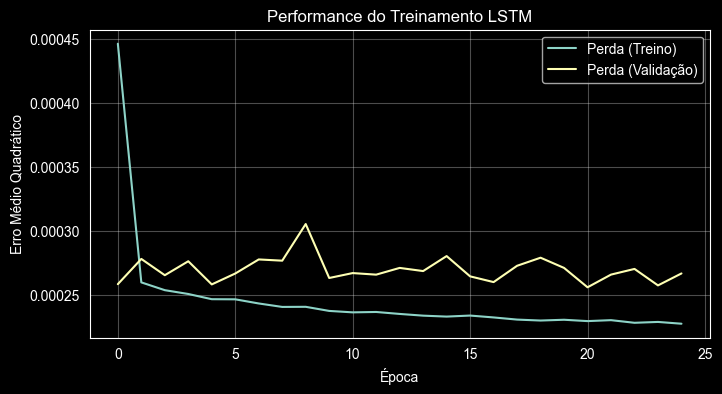

11689/11689 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step


In [5]:
if X_train.shape[0] > 0:
    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(N_STEPS, 3), return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='tanh'),
        Dense(2)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    
    print("\n--- Iniciando Treinamento Global Acelerado ---\n")
    # Armazenamos o histórico de treinamento
    history = model.fit(X_train, y_train, epochs=25, batch_size=64, verbose=1, validation_split=0.2)
    
    # --- GRÁFICO DE PERFORMANCE DE TREINAMENTO ---
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Perda (Treino)')
    plt.plot(history.history['val_loss'], label='Perda (Validação)')
    plt.title('Performance do Treinamento LSTM')
    plt.xlabel('Época')
    plt.ylabel('Erro Médio Quadrático')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Cálculo do Erro Comportamental
    y_pred = model.predict(X_train)
    errors = np.linalg.norm(y_train - y_pred, axis=1)
    
    df_analysis['score_comportamental'] = 0.0
    for i, idx in enumerate(target_indices):
        if idx in df_analysis.index:
            df_analysis.at[idx, 'score_comportamental'] = float(errors[i])

## 5. Investigação de Estudos de Caso (Análise Forense)

In [9]:
def format_timedelta(hours_decimal):
    td = timedelta(hours=hours_decimal)
    total_seconds = int(td.total_seconds())
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

def apresentar_estudo_caso(df_subset, titulo, cor_mapa):
    display(HTML(f"<h2 style='color:{cor_mapa}; border-bottom: 2px solid {cor_mapa};'>{titulo}</h2>"))
    if df_subset.empty: return
        
    top_casos = df_subset.sort_values(by=['speed_kmh', 'score_comportamental'], ascending=False).head(4)
    threshold = df_analysis['score_comportamental'].mean() + (2 * df_analysis['score_comportamental'].std())
    
    for i, (idx, row) in enumerate(top_casos.iterrows()):
        print(f"CASO #{i+1}")
        print(f"Usuário: {row['Usuário']}")
        print(f"Origem:\n    - Horário: {row['prev_data']}\n    - Cidade: {row['prev_cidade']}\n    - Log: {row['prev_full_log']}")
        print(f"Destino:\n    - Horário: {row['Data']}\n    - Cidade: {row['cidade']}\n    - Log: {row['full_log']}")
        print(f"Velocidade Calculada: {row['speed_kmh']:.2f} km/h")
        print(f"Diferença Temporal: {format_timedelta(row['time_diff_hours'])} (HH:MM:SS)")
        print(f"Distância: {row['min_dist_km']:.2f} km")
        
        is_anomalous = row['score_comportamental'] > threshold
        print(f"Score Comportamental (LSTM): {row['score_comportamental']:.6f} ({'ANÔMALO' if is_anomalous else 'ESPERADO'})")
        
        m = folium.Map(location=[(row['prev_lat']+row['latitude'])/2, (row['prev_lon']+row['longitude'])/2], zoom_start=2)
        folium.Marker([row['prev_lat'], row['prev_lon']], icon=folium.Icon(color='blue')).add_to(m)
        folium.Marker([row['latitude'], row['longitude']], icon=folium.Icon(color='red')).add_to(m)
        folium.PolyLine([[row['prev_lat'], row['prev_lon']], [row['latitude'], row['longitude']]], color=cor_mapa, weight=3).add_to(m)
        display(m)
        
        # Adição da Ação Adicional: Link externo para o Google Maps
        gmaps_link = f"https://www.google.com/maps/dir/{row['prev_lat']},{row['prev_lon']}/{row['latitude']},{row['longitude']}/"
        display(HTML(f'<b>Ação Adicional:</b> <a href="{gmaps_link}" target="_blank">Ver detalhes no Google Maps Externo</a>'))
        
        print("-" * 80)

alta = df_analysis[df_analysis['speed_kmh'] > 1000]
apresentar_estudo_caso(alta, "Alta Prioridade (Detecção Crítica)", "#d9534f")

CASO #1
Usuário: USR502440@acme-d67a0e6c.org.br
Origem:
    - Horário: 2025-01-07 12:08:03-03:00
    - Cidade: Woldingham
    - Log: 2025-01-07T12:08:03-0300;USR502440@acme-d67a0e6c.org.br;login_success;51.28348;-0.0352;10.0;Woldingham;USR502440@acme-d67a0e6c.org.br logged in
Destino:
    - Horário: 2025-01-07 12:08:10-03:00
    - Cidade: São Paulo
    - Log: 2025-01-07T12:08:10-0300;USR502440@acme-d67a0e6c.org.br;login_success;-23.6293;-46.6351;20.0;São Paulo;USR502440@acme-d67a0e6c.org.br logged in
Velocidade Calculada: 4865676.71 km/h
Diferença Temporal: 00:00:07 (HH:MM:SS)
Distância: 9461.04 km
Score Comportamental (LSTM): 0.000000 (ESPERADO)


--------------------------------------------------------------------------------
CASO #2
Usuário: USR448151@acme-d67a0e6c.org.br
Origem:
    - Horário: 2025-04-28 12:54:38-03:00
    - Cidade: São Paulo
    - Log: 2025-04-28T12:54:38-0300;USR448151@acme-d67a0e6c.org.br;login_success;-23.5475;-46.6361;5.0;São Paulo;USR448151@acme-d67a0e6c.org.br logged in
Destino:
    - Horário: 2025-04-28 12:54:39-03:00
    - Cidade: Ituiutaba
    - Log: 2025-04-28T12:54:39-0300;USR448151@acme-d67a0e6c.org.br;login_success;-19.0137;-49.5496;5.0;Ituiutaba;USR448151@acme-d67a0e6c.org.br logged in
Velocidade Calculada: 2079165.54 km/h
Diferença Temporal: 00:00:01 (HH:MM:SS)
Distância: 577.55 km
Score Comportamental (LSTM): 0.046240 (ANÔMALO)


--------------------------------------------------------------------------------
CASO #3
Usuário: USR459166@acme-043bf1cc.org.br
Origem:
    - Horário: 2025-05-09 09:49:02-03:00
    - Cidade: Naaldwijk
    - Log: 2025-05-09T09:49:02-0300;USR459166@acme-043bf1cc.org.br;login_success;51.9968;4.2057;20.0;Naaldwijk;USR459166@acme-043bf1cc.org.br logged in
Destino:
    - Horário: 2025-05-09 09:49:19-03:00
    - Cidade: São Paulo
    - Log: 2025-05-09T09:49:19-0300;USR459166@acme-043bf1cc.org.br;login_success;-23.6293;-46.6351;10.0;São Paulo;USR459166@acme-043bf1cc.org.br logged in
Velocidade Calculada: 2058409.95 km/h
Diferença Temporal: 00:00:17 (HH:MM:SS)
Distância: 9720.27 km
Score Comportamental (LSTM): 0.477290 (ANÔMALO)


--------------------------------------------------------------------------------
CASO #4
Usuário: USR975404@acme-4cdbb9e8.org.br
Origem:
    - Horário: 2025-01-26 20:35:47-03:00
    - Cidade: Amsterdam
    - Log: 2025-01-26T20:35:47-0300;USR975404@acme-4cdbb9e8.org.br;login_success;52.13263;5.29127;50.0;Amsterdam;USR975404@acme-4cdbb9e8.org.br logged in
Destino:
    - Horário: 2025-01-26 20:36:09-03:00
    - Cidade: São Paulo
    - Log: 2025-01-26T20:36:09-0300;USR975404@acme-4cdbb9e8.org.br;login_success;-23.5475;-46.6361;5.0;São Paulo;USR975404@acme-4cdbb9e8.org.br logged in
Velocidade Calculada: 1595626.26 km/h
Diferença Temporal: 00:00:22 (HH:MM:SS)
Distância: 9751.05 km
Score Comportamental (LSTM): 0.257159 (ANÔMALO)


--------------------------------------------------------------------------------


## 6. Conclusão e Exportação

In [7]:
alta.to_csv('alertas_prioridade_alta.csv', index=False, sep=';')
print("Análise finalizada com diagnóstico de performance de treino.")

Análise finalizada com diagnóstico de performance de treino.
